In [176]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
import matplotlib.gridspec as gridspec
from scipy.stats import pearsonr
import warnings
warnings.filterwarnings('ignore')

# Repertory Grid Data

In [177]:
CONSTRUCTS = [
    "Strong_Hold",
    "Smooth_Surface",
    "Controlled_Heat",
    "Process_Safety",
    "Minimal_Deformation",
    "Regular_Shape",
    "Proper_Alignment",
    "Consistent_Nugget"
]

In [178]:
ELEMENTS = ["E1-Ideal", "E2-Overheated", "E3-WeakBond", "E4-Distorted", "E5-Misaligned"]

In [179]:
# Original ratings (rows=constructs, cols=elements)
RATINGS = np.array([
    [7, 3, 1, 4, 4],  # Strong Hold
    [7, 2, 6, 4, 3],  # Smooth Surface
    [7, 1, 5, 4, 5],  # Controlled Heat
    [7, 1, 3, 4, 4],  # Process Safety
    [7, 1, 6, 3, 3],  # Minimal Deformation
    [7, 3, 5, 2, 1],  # Regular Shape
    [7, 5, 5, 3, 1],  # Proper Alignment
    [7, 2, 5, 3, 4],  # Consistent Nugget
])

In [180]:
# Corrected ratings based on analysis
CORRECTED_RATINGS = np.array([
    [7, 3, 1, 3, 2],  # Strong Hold       (E4: 4→3, E5: 4→2)
    [7, 2, 6, 4, 3],  # Smooth Surface     (unchanged)
    [7, 1, 2, 4, 4],  # Controlled Heat   (E3: 5→2)
    [7, 1, 3, 4, 4],  # Process Safety     (unchanged)
    [7, 1, 6, 3, 3],  # Minimal Deformation(unchanged)
    [7, 3, 5, 2, 1],  # Regular Shape      (unchanged)
    [7, 5, 5, 3, 1],  # Proper Alignment   (unchanged)
    [7, 2, 2, 3, 2],  # Consistent Nugget (E3: 5→2, E5: 4→2)
])
 

# FCM Node Definitions


In [181]:
# We use the 6 most distinct constructs as FCM nodes
# (removing redundant "Regular Shape" and vague "Process Safety
FCM_NODES = [
    "Strong_Hold",
    "Smooth_Surface",
    "Controlled_Heat",
    "Minimal_Deformation",
    "Proper_Alignment",
    "Consistent_Nugget"
]

In [182]:

FCM_IDX = {name: i for i, name in enumerate(FCM_NODES)}
N = len(FCM_NODES)

N

6

# CALCULATE ADJACENCY MATRIX FROM REPERTORY GRID


In [183]:
def compute_adjacency_matrix(ratings, node_names, all_constructs):
    """
    Compute FCM adjacency matrix using Pearson correlation
    between construct pairs derived from Repertory Grid ratings.
    Diagonal is always 0 (no self-influence).
    """
    # Select only rows matching FCM nodes
    indices = [all_constructs.index(n) for n in node_names]
    selected = ratings[indices, :]   # shape: (N, n_elements)
 
    n = len(node_names)
    F = np.zeros((n, n))
 
    for i in range(n):
        for j in range(n):
            if i == j:
                F[i][j] = 0
            else:
                r, _ = pearsonr(selected[i], selected[j])
                F[i][j] = round(r, 2)
 
    return F

In [184]:
def print_adjacency_matrix(F, labels, title="Adjacency Matrix"):
    print(f"\n{'='*60}")
    print(f"  {title}")
    print(f"{'='*60}")
    df = pd.DataFrame(F, index=labels, columns=labels)
    print(df.round(2).to_string())
    print(f"{'='*60}")

# FCM SIMULATION


In [185]:
def sigmoid(x, lam=1.0):
    """Sigmoid transfer function mapped to [-1, +1]"""
    return (2 / (1 + np.exp(-lam * x))) - 1

In [186]:
def run_fcm(input_vector, F, max_iter=50, threshold=0.0001, lam=1.0):
    """
    Run FCM simulation until convergence.
    Returns: final state, history of all states
    """
    state = np.array(input_vector, dtype=float)
    history = [state.copy()]
 
    for i in range(max_iter):
        new_state = sigmoid(np.dot(state, F), lam)
        history.append(new_state.copy())
 
        if np.max(np.abs(new_state - state)) < threshold:
            print(f"  ✓ Converged at iteration {i+1}")
            break
        state = new_state
    else:
        print(f"  ⚠ Did not fully converge after {max_iter} iterations")
 
    return state, history

In [187]:
def normalize_ratings(ratings_row, midpoint=4, max_dev=3):
    """Convert 1-7 scale ratings to -1/+1 FCM scale"""
    return (np.array(ratings_row, dtype=float) - midpoint) / max_dev

In [188]:
def interpret_value(v):
    """Interpret FCM node value as status"""
    if v >= 0.6:   return "EXCELLENT ✓✓"
    elif v >= 0.3: return "GOOD      ✓"
    elif v >= 0.0: return "FAIR      ~"
    elif v >= -0.3:return "WARNING   !"
    elif v >= -0.6:return "POOR      !!"
    else:          return "CRITICAL  ✗"

#  SCENARIO DEFINITIONS


In [189]:
def build_scenarios(corrected_ratings, all_constructs, fcm_nodes):
    """
    Build input vectors for each weld element scenario
    by normalizing corrected Repertory Grid ratings.
    """
    indices = [all_constructs.index(n) for n in fcm_nodes]
    scenarios = {}
 
    element_names = {
        0: "E1 - Ideal Weld",
        1: "E2 - Overheated Weld",
        2: "E3 - Weak Bond Weld",
        3: "E4 - Distorted Contact",
        4: "E5 - Misaligned Weld",
    }
 
    for col, name in element_names.items():
        raw = corrected_ratings[indices, col]
        normalized = normalize_ratings(raw)
        scenarios[name] = normalized
 
    # Additional custom scenarios
    scenarios["E6 - Cold Weld (NEW)"] = normalize_ratings(
        np.array([1, 6, 1, 6, 5, 1]))  # low strength, clean surface, low heat
    scenarios["E7 - Expulsion Weld (NEW)"] = normalize_ratings(
        np.array([4, 1, 1, 2, 3, 3]))  # moderate strength, very bad surface
 
    return scenarios

# visualization


In [190]:
def plot_convergence(history, node_labels, scenario_name, ax):
    """Plot FCM state convergence over iterations"""
    history_arr = np.array(history)
    colors = plt.cm.tab10(np.linspace(0, 1, len(node_labels)))
 
    for i, (label, color) in enumerate(zip(node_labels, colors)):
        ax.plot(history_arr[:, i], marker='o', markersize=3,
                label=label, color=color, linewidth=2)
 
    ax.axhline(0, color='black', linestyle='--', alpha=0.3)
    ax.set_title(f"Convergence: {scenario_name}", fontsize=10, fontweight='bold')
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Node Value (-1 to +1)")
    ax.legend(fontsize=7, loc='upper right')
    ax.set_ylim(-1.1, 1.1)
    ax.grid(True, alpha=0.3)
    ax.fill_between(range(len(history_arr)), -0.3, 0.3, alpha=0.05, color='yellow')
    ax.fill_between(range(len(history_arr)), 0.3, 1.1, alpha=0.05, color='green')
    ax.fill_between(range(len(history_arr)), -1.1, -0.3, alpha=0.05, color='red')

In [191]:
def plot_radar(final_states, scenario_names, node_labels):
    """Radar chart comparing all scenarios"""
    n_nodes = len(node_labels)
    angles = np.linspace(0, 2 * np.pi, n_nodes, endpoint=False).tolist()
    angles += angles[:1]
 
    fig, ax = plt.subplots(figsize=(9, 9),
                           subplot_kw=dict(polar=True))
    colors = plt.cm.tab10(np.linspace(0, 1, len(scenario_names)))
 
    for (name, state), color in zip(final_states.items(), colors):
        values = list(state) + [state[0]]
        ax.plot(angles, values, 'o-', linewidth=2, label=name, color=color)
        ax.fill(angles, values, alpha=0.05, color=color)
 
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(node_labels, size=9)
    ax.set_ylim(-1, 1)
    ax.set_yticks([-1, -0.5, 0, 0.5, 1])
    ax.set_yticklabels(['-1', '-0.5', '0', '0.5', '1'], size=7)
    ax.set_title("RSW Weld Quality — FCM Radar Comparison",
                 size=13, fontweight='bold', pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=8)
    ax.grid(True)
 
    plt.tight_layout()
    plt.close()


In [192]:
def plot_heatmap(F, labels, title):
    """Heatmap of adjacency matrix"""
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(F, cmap='RdYlGn', vmin=-1, vmax=1)
    plt.colorbar(im, ax=ax, label='Weight (-1 to +1)')
 
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(labels, fontsize=9)
 
    for i in range(len(labels)):
        for j in range(len(labels)):
            val = F[i][j]
            color = 'white' if abs(val) > 0.5 else 'black'
            ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                    fontsize=8, color=color, fontweight='bold')
 
    ax.set_title(title, fontsize=12, fontweight='bold', pad=15)
    ax.set_xlabel("Effect Node")
    ax.set_ylabel("Cause Node")
    
    plt.tight_layout()
    plt.show()

In [193]:
def plot_bar_comparison(final_states, node_labels):
    """Bar chart comparing final FCM states across scenarios"""
    scenarios = list(final_states.keys())
    n_scenarios = len(scenarios)
    n_nodes = len(node_labels)
    x = np.arange(n_nodes)
    width = 0.12
 
    fig, ax = plt.subplots(figsize=(14, 6))
    colors = plt.cm.tab10(np.linspace(0, 1, n_scenarios))
 
    for i, (name, state) in enumerate(final_states.items()):
        offset = (i - n_scenarios / 2) * width + width / 2
        bars = ax.bar(x + offset, state, width, label=name,
                      color=colors[i], alpha=0.8, edgecolor='white')
 
    ax.axhline(0, color='black', linewidth=0.8)
    ax.axhline(0.3, color='green', linewidth=0.8, linestyle='--', alpha=0.4)
    ax.axhline(-0.3, color='red', linewidth=0.8, linestyle='--', alpha=0.4)
    ax.set_xticks(x)
    ax.set_xticklabels(node_labels, rotation=20, ha='right', fontsize=9)
    ax.set_ylabel("FCM Node Value (-1 to +1)")
    ax.set_title("RSW Weld Quality — Final FCM State Comparison",
                 fontsize=12, fontweight='bold')
    ax.legend(fontsize=7, loc='upper right')
    ax.set_ylim(-1.1, 1.1)
    ax.grid(True, axis='y', alpha=0.3)
 
    # Zone labels
    ax.text(n_nodes - 0.5, 0.65, 'GOOD ZONE', color='green',
            fontsize=8, alpha=0.6)
    ax.text(n_nodes - 0.5, -0.65, 'CRITICAL ZONE', color='red',
            fontsize=8, alpha=0.6)
 
    plt.tight_layout()
    plt.show()

In [194]:
def plot_convergence_grid(all_histories, node_labels):
    """Plot convergence for all scenarios in a grid"""
    scenarios = list(all_histories.keys())
    n = len(scenarios)
    cols = 2
    rows = (n + 1) // cols
 
    fig, axes = plt.subplots(rows, cols, figsize=(14, rows * 4))
    axes = axes.flatten()
 
    for i, (name, history) in enumerate(all_histories.items()):
        plot_convergence(history, node_labels, name, axes[i])
 
    # Hide unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
 
    fig.suptitle("RSW FCM — Convergence for All Scenarios",
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

In [195]:
def plot_repertory_grid_heatmap(ratings, constructs, elements):
    """Visualize original vs corrected repertory grid"""
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
 
    for ax, data, title in zip(
        axes,
        [RATINGS, CORRECTED_RATINGS],
        ["Original Ratings", "Corrected Ratings"]
    ):
        im = ax.imshow(data, cmap='RdYlGn', vmin=1, vmax=7, aspect='auto')
        plt.colorbar(im, ax=ax, label='Score (1=Failure, 7=Ideal)')
        ax.set_xticks(range(len(elements)))
        ax.set_yticks(range(len(constructs)))
        ax.set_xticklabels(elements, rotation=30, ha='right', fontsize=9)
        ax.set_yticklabels(constructs, fontsize=9)
        ax.set_title(title, fontsize=11, fontweight='bold')
 
        for i in range(len(constructs)):
            for j in range(len(elements)):
                val = data[i][j]
                color = 'white' if val < 3 else 'black'
                ax.text(j, i, str(val), ha='center', va='center',
                        fontsize=10, color=color, fontweight='bold')
 
    plt.suptitle("Repertory Grid Analysis — RSW Weld Quality",
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()  
 

# Report generator


In [196]:
def print_full_report(scenarios, final_states, F, node_labels):
    print("\n" + "="*65)
    print("   RSW FUZZY COGNITIVE MAP — FULL ANALYSIS REPORT")
    print("   Chonnam National University — Team 4")
    print("="*65)
 
    print("\n📌 ADJACENCY MATRIX (Pearson correlation from Repertory Grid)")
    print_adjacency_matrix(F, node_labels, "FCM Adjacency Matrix")
 
    print("\n📌 STRONGEST RELATIONSHIPS FOUND:")
    pairs = []
    for i in range(len(node_labels)):
        for j in range(len(node_labels)):
            if i != j and abs(F[i][j]) >= 0.4:
                pairs.append((abs(F[i][j]), F[i][j], node_labels[i], node_labels[j]))
    pairs.sort(reverse=True)
    for abs_val, val, cause, effect in pairs[:8]:
        direction = "positively" if val > 0 else "negatively"
        print(f"  {cause:22s} → {effect:22s}: {val:+.2f} ({direction})")
 
    print("\n📌 SCENARIO RESULTS:")
    print(f"  {'Scenario':<30} | {'Best Node':<22} | {'Worst Node':<22} | Overall")
    print("  " + "-"*90)
 
    for name, state in final_states.items():
        best_idx = np.argmax(state)
        worst_idx = np.argmin(state)
        overall = np.mean(state)
        status = interpret_value(overall)
        print(f"  {name:<30} | {node_labels[best_idx]:<22} | "
              f"{node_labels[worst_idx]:<22} | {overall:+.3f} {status}")
 
    print("\n📌 DETAILED NODE VALUES PER SCENARIO:")
    for name, state in final_states.items():
        print(f"\n  [{name}]")
        for node, val in zip(node_labels, state):
            bar = "█" * int((val + 1) * 10) + "░" * int((1 - val) * 10)
            print(f"    {node:22s}: {val:+.3f}  {bar}  {interpret_value(val)}")
 
    print("\n📌 RECOMMENDATIONS:")
    recommendations = {
        "E1 - Ideal Weld":           "✓ Maintain current parameters — benchmark quality achieved",
        "E2 - Overheated Weld":      "↓ Reduce welding current by ~15-20%, shorten weld time",
        "E3 - Weak Bond Weld":       "↑ Increase current and time — cold weld forming, check nugget",
        "E4 - Distorted Contact":    "⚙ Check electrode condition and contact pressure uniformity",
        "E5 - Misaligned Weld":      "⚠ STOP — realign electrodes before continuing production",
        "E6 - Cold Weld (NEW)":      "↑ Significantly increase current — insufficient fusion detected",
        "E7 - Expulsion Weld (NEW)": "↓ Reduce current immediately — metal ejection is occurring",
    }
    for name, rec in recommendations.items():
        print(f"  {name:<30}: {rec}")

 

In [197]:
# Step 1: Compute adjacency matrix
print("Step 1: Computing adjacency matrix from Repertory Grid...")
F = compute_adjacency_matrix(CORRECTED_RATINGS, FCM_NODES, CONSTRUCTS)

Step 1: Computing adjacency matrix from Repertory Grid...


In [198]:
 # Step 2: Build scenarios
print("Step 2: Building weld scenarios...")
scenarios = build_scenarios(CORRECTED_RATINGS, CONSTRUCTS, FCM_NODES)

Step 2: Building weld scenarios...


In [199]:
# Step 3: Run FCM for each scenario
print("⚙  Step 3: Running FCM simulations...")
final_states = {}
all_histories = {}

for name, input_vec in scenarios.items():
    print(f"\n  Scenario: {name}")
    print(f"  Input:    {np.round(input_vec, 2)}")
    final, history = run_fcm(input_vec, F)
    final_states[name] = final
    all_histories[name] = history

⚙  Step 3: Running FCM simulations...

  Scenario: E1 - Ideal Weld
  Input:    [1. 1. 1. 1. 1. 1.]
  ✓ Converged at iteration 7

  Scenario: E2 - Overheated Weld
  Input:    [-0.33 -0.67 -1.   -1.    0.33 -0.67]
  ✓ Converged at iteration 9

  Scenario: E3 - Weak Bond Weld
  Input:    [-1.    0.67 -0.67  0.67  0.33 -0.67]
  ✓ Converged at iteration 13

  Scenario: E4 - Distorted Contact
  Input:    [-0.33  0.    0.   -0.33 -0.33 -0.33]
  ✓ Converged at iteration 12

  Scenario: E5 - Misaligned Weld
  Input:    [-0.67 -0.33  0.   -0.33 -1.   -0.67]
  ✓ Converged at iteration 10

  Scenario: E6 - Cold Weld (NEW)
  Input:    [-1.    0.67 -1.    0.67  0.33 -1.  ]
  ✓ Converged at iteration 11

  Scenario: E7 - Expulsion Weld (NEW)
  Input:    [ 0.   -1.   -1.   -0.67 -0.33 -0.33]
  ✓ Converged at iteration 9



 Step 4: Generating visualizations...


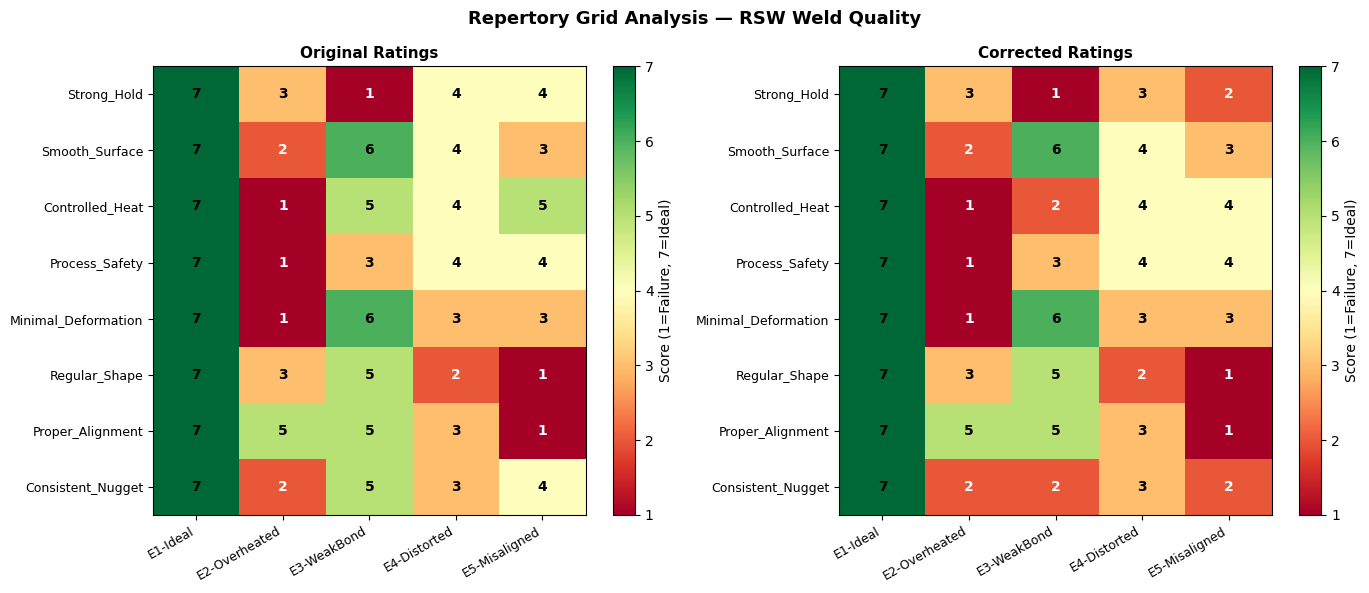

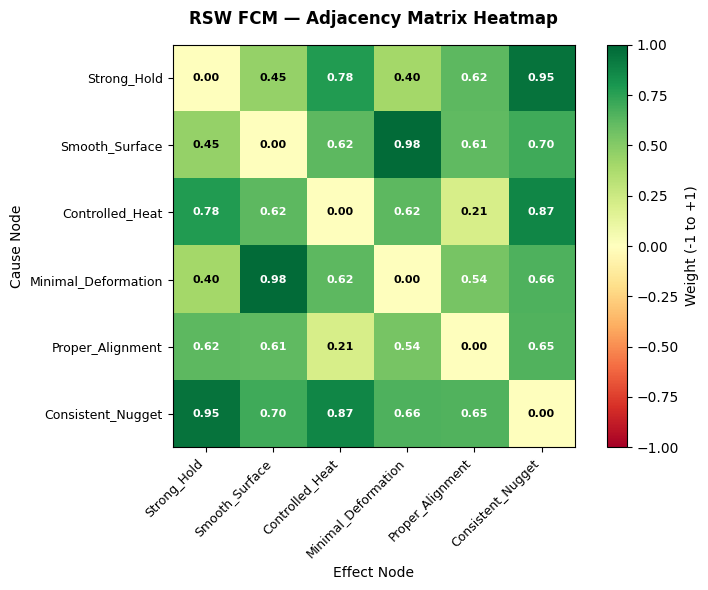

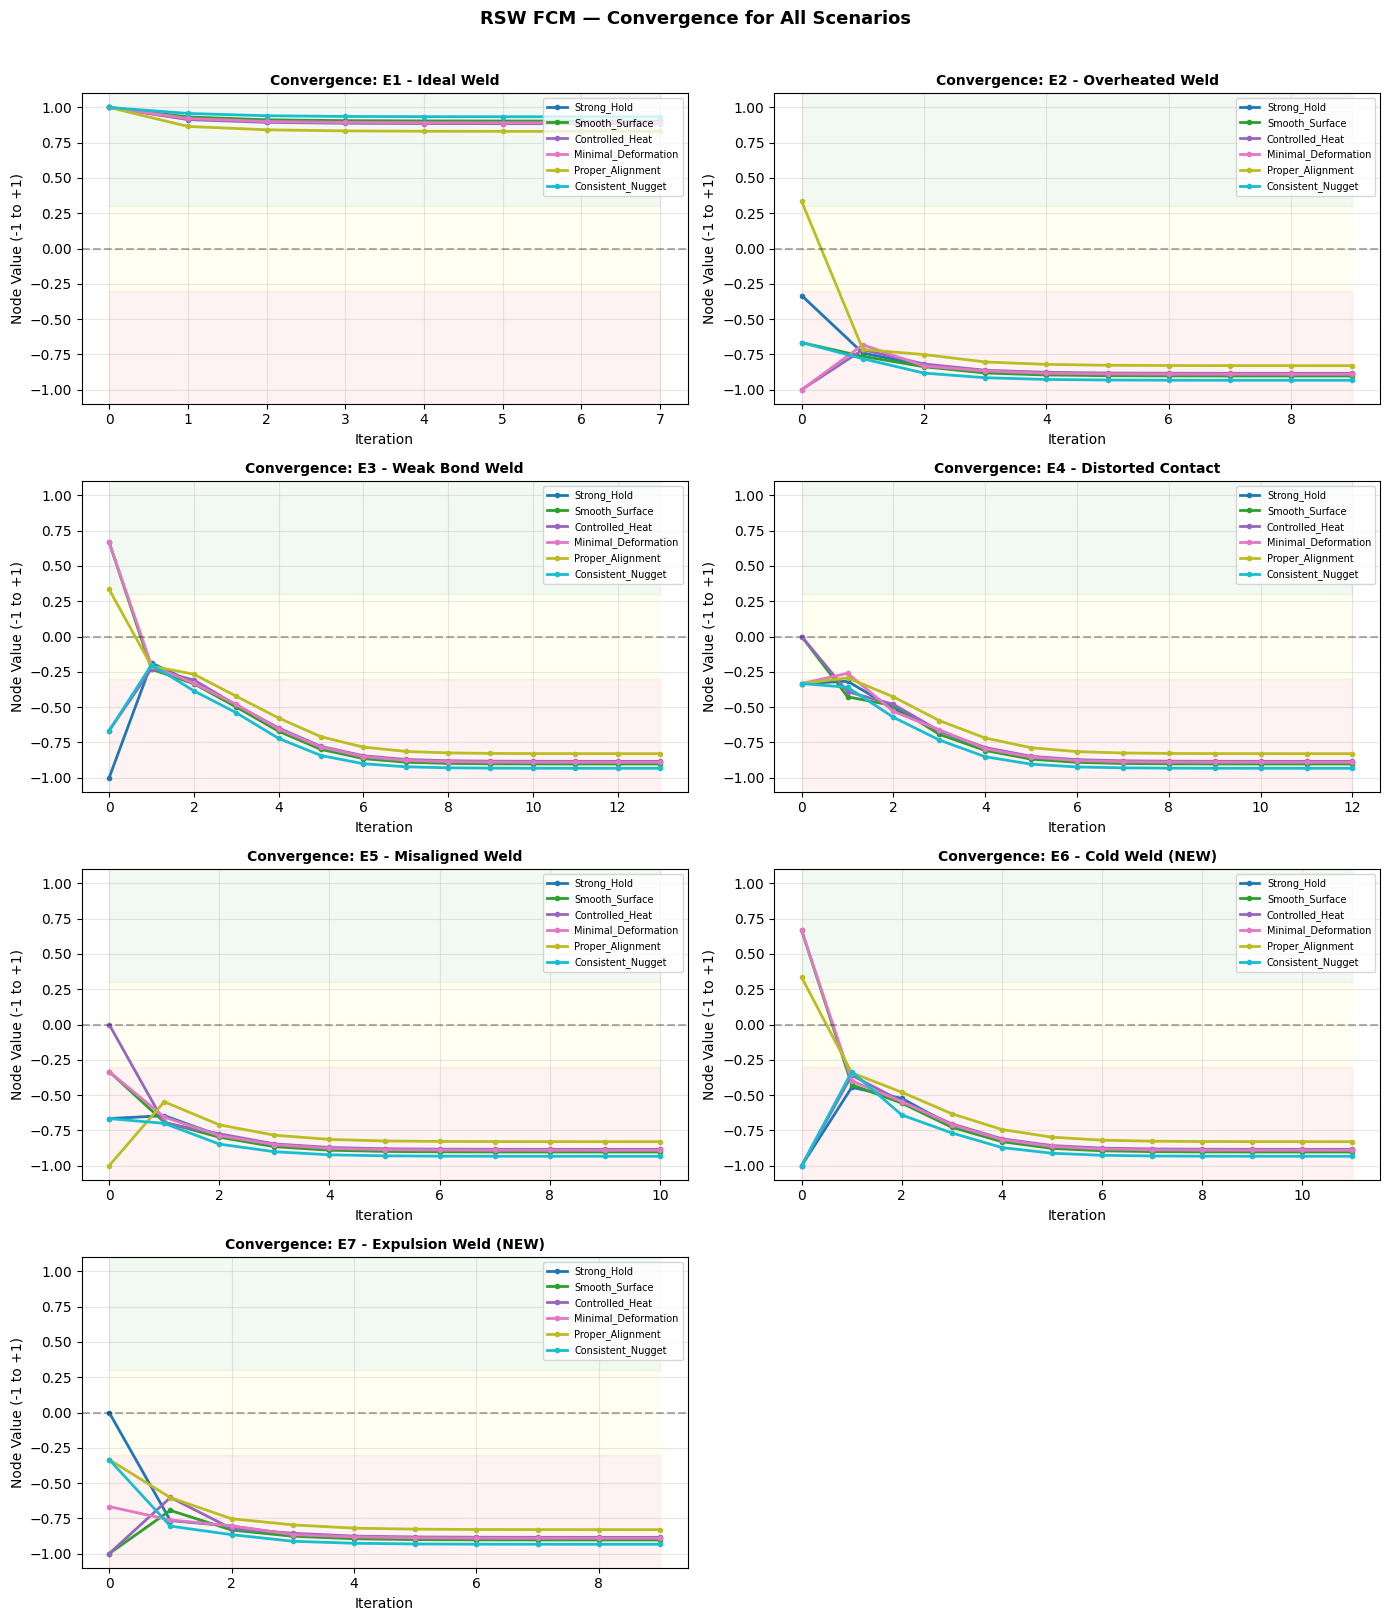

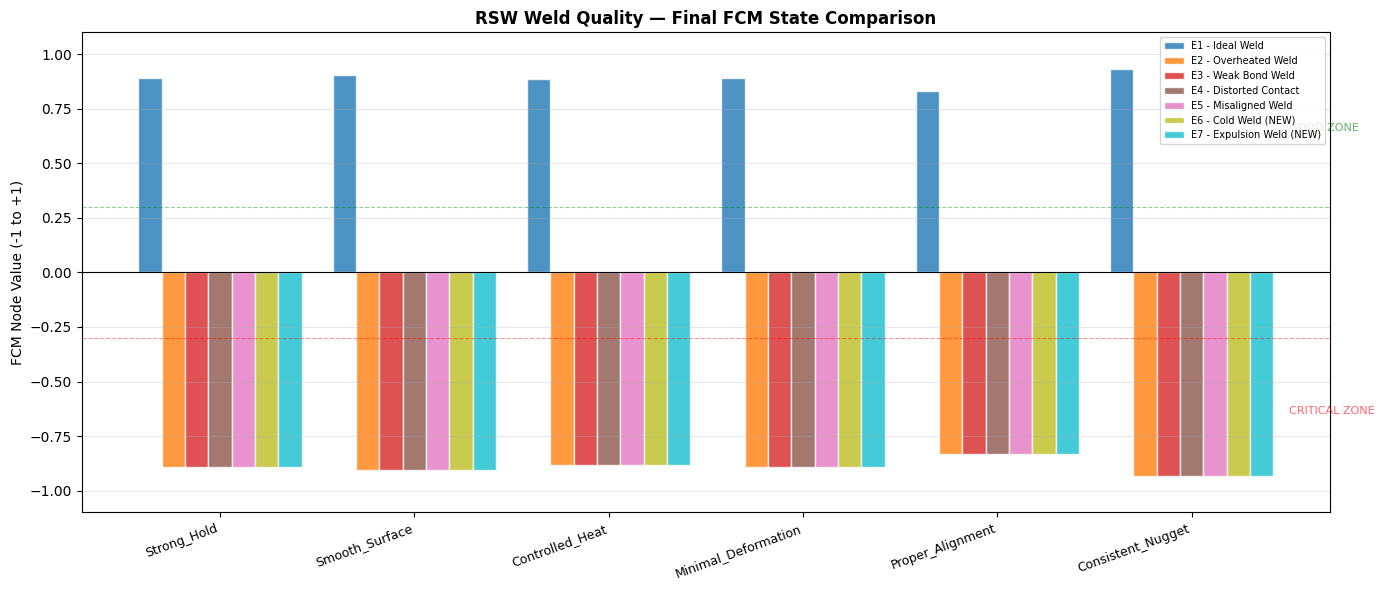


   RSW FUZZY COGNITIVE MAP — FULL ANALYSIS REPORT
   Chonnam National University — Team 4

📌 ADJACENCY MATRIX (Pearson correlation from Repertory Grid)

  FCM Adjacency Matrix
                     Strong_Hold  Smooth_Surface  Controlled_Heat  Minimal_Deformation  Proper_Alignment  Consistent_Nugget
Strong_Hold                 0.00            0.45             0.78                 0.40              0.62               0.95
Smooth_Surface              0.45            0.00             0.62                 0.98              0.61               0.70
Controlled_Heat             0.78            0.62             0.00                 0.62              0.21               0.87
Minimal_Deformation         0.40            0.98             0.62                 0.00              0.54               0.66
Proper_Alignment            0.62            0.61             0.21                 0.54              0.00               0.65
Consistent_Nugget           0.95            0.70             0.87              

In [200]:
# Step 4: Generate visualizations
print("\n Step 4: Generating visualizations...")
plot_repertory_grid_heatmap(RATINGS, CONSTRUCTS, ELEMENTS)
plot_heatmap(F, FCM_NODES, "RSW FCM — Adjacency Matrix Heatmap")
plot_convergence_grid(all_histories, FCM_NODES)
plot_radar(final_states, list(scenarios.keys()), FCM_NODES)
plot_bar_comparison(final_states, FCM_NODES)
 
# Step 5: Print full report
print_full_report(scenarios, final_states, F, FCM_NODES)

If two constructs behave similarly across all elements
→ they are strongly related → high positive weight

If they behave oppositely
→ they are negatively related → negative weight

If no pattern
→ weight close to 0